<a href="https://colab.research.google.com/github/SanjaraT/Sentiment-Analysis-BERT/blob/main/Bengali_sentiment_analysis_XLMRoberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer
from transformers import XLMRobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [ ]:
def load_data(pos_path, neg_path):
  with open(pos_path, encoding='utf-8') as f:
    pos = f.readlines()

  with open(neg_path, encoding='utf-8') as f:
    neg = f.readlines()

    texts = pos + neg
    labels = [1]*len(pos) + [0]*len(neg)

    return pd.DataFrame({'text': texts, 'label': labels})

df = load_data(
    "/content/drive/MyDrive/Beng_sent_data/all_positive_8500.txt",
    "/content/drive/MyDrive/Beng_sent_data/all_negative_3307.txt"
)

df = df.sample(frac=1).reset_index(drop=True)
df.head()

,text,label
0,মিজানুর রহমার আরিয়ানের প্রতিটা নাটক মুগ্ধ করা...,1
1,অসাধারণ হয়েছে নাটক\n,1
2,নাটক টা দারুণ লাগচে\n,1
3,অনেক ভালো লাগলো\n,1
4,শালার পো কি করবি এইভাবে টিপে টপে কি দেখাছ কি ব...,0


In [ ]:
df.shape

(11807, 2)

# Train-Test

In [ ]:
from numpy import random
from sklearn.model_selection import train_test_split

train_text, test_text, train_label, test_label = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size = 0.1,
    random_state = 42,
    stratify=df['label']
)

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_label),
    y=train_label
)

weights = torch.tensor(weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

# Tokenization

In [ ]:
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')

def tokenize(texts):
  return tokenizer(
      texts,
      padding=True,
      truncation=True,
      max_length=512,
      return_tensors='pt'
  )

train_encodings = tokenize(train_text)
test_encodings = tokenize(test_text)

# Custom Dataset Class

In [ ]:
class SentimentDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self, idx):
    item = {key: val[idx] for key, val in self.encodings.items()}
    item['labels'] = torch.tensor(self.labels[idx])
    return item

  def __len__(self):
    return len(self.labels)

In [ ]:
# Dataset Object
train_dataset = SentimentDataset(train_encodings, train_label)
test_dataset = SentimentDataset(test_encodings, test_label)

In [ ]:
# Dataloader object
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Model

In [ ]:
model = XLMRobertaForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

#

In [ ]:
# Moving Model to GPU
model.to(device)

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5)

# Training Pipeline

In [ ]:
from tqdm import tqdm

for epoch in range(3):
    model.train()
    loop = tqdm(train_loader, leave=True)
    total_loss = 0

    for batch in loop:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        # weighted loss
        loss = loss_fn(logits, labels)

        total_loss += loss.item()

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} finished | Avg Loss: {total_loss/len(train_loader):.4f}")

Epoch 1: 100%|██████████| 665/665 [17:34<00:00,  1.59s/it, loss=0.00718]


Epoch 1 finished | Avg Loss: 0.3226


Epoch 2: 100%|██████████| 665/665 [17:39<00:00,  1.59s/it, loss=0.0056]


Epoch 2 finished | Avg Loss: 0.1588


Epoch 3: 100%|██████████| 665/665 [17:40<00:00,  1.60s/it, loss=0.000932]

Epoch 3 finished | Avg Loss: 0.1166


# Evaluation

In [ ]:
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predictions = torch.argmax(logits, dim=1).cpu().numpy()

        preds.extend(predictions)
        true_labels.extend(batch['labels'].numpy())

print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds))

Accuracy: 0.955969517358171
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       331
           1       0.97      0.96      0.97       850

    accuracy                           0.96      1181
   macro avg       0.94      0.95      0.95      1181
weighted avg       0.96      0.96      0.96      1181



# Inference

In [ ]:
def predict(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

    return "Positive" if pred == 1 else "Negative"

# Test
print(predict("নাটকটি অসাধারণ ছিল"))
print(predict("পুরা সময়টাই নষ্ট"))

Positive
Negative


# Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
cm = confusion_matrix(true_labels, preds)

print(cm)

[[310  21]
 [ 31 819]]


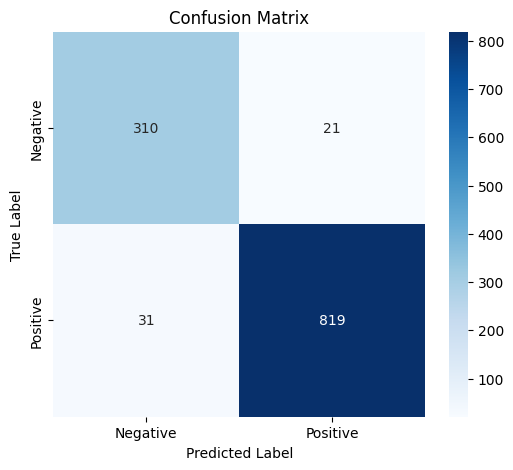

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Error Analysis

In [ ]:
misclassified = []

for text, pred, true in zip(test_text, preds, true_labels):

    if pred != true:

        misclassified.append({
            "text": text,
            "predicted": pred,
            "actual": true
        })
        error_df = pd.DataFrame(misclassified)

print(error_df.head())
print("Total Misclassified:", len(misclassified))

                                                text  predicted  actual
0   বাংলা নাটক গুলো আসলেও নাটকীয় বাস্তব এর সাথে ...          1       0
1                                   বাস্তব বড় কঠিন\n          0       1
2                                       তিশা সেই!!\n          0       1
3                 এই নাটক টা দেখে মনটা জুরিয়ে গেছে\n          0       1
4   আপু সবার যেই আকারে ভাইরাল ভিডিও বের হচ্ছে,তোম...          0       1
Total Misclassified: 52
